# Práctica entregable: Segmentación de imaxes con Deep Learning

-----
Notas importantes para a entrega: teredes que entregar un arquivo comprimido en formato .zip co formato `Apelidos_Nome_P5.zip` (sen acentos nin caracteres especiais, p.ex., PerezGarcia_Juan_P5.zip), que conterá dous arquivos.
- Este Jupyter Notebook cos exercicios resoltos e todas as celdas executadas (de tal maneira que se poidan ver os resultados), que terá o nome `Apelidos_Nome_P5.ipynb`
- O mesmo notebook exportado a HTML, co nome `Apelidos_Nome_P5.html`. Do mesmo xeito, deberedes ter todas as celdas executadas antes de exportalo, para que se poidan ver os resultados.
-----

Nesta práctica imos traballar directamente con modelos de Deep Learning orientados á segmentación de imaxes, utilizando distintas arquitecturas do estado da arte. Dado que o adestramento destes sistemas pode ser computacionalmente intensivo, recoméndase empregar Google Colab ou, de non ser suficiente, o clúster de computación do CESGA.

O conxunto de datos que empregaremos será de novo o *FruitSeg30*, que xa utilizamos na práctica anterior. Se non o fixeches, descarga e descomprime dito conxunto executando a celda seguinte:

In [1]:
from pathlib import Path
import zipfile
from urllib import request

import torch
from torch import nn
from torchvision.transforms import functional as TF

In [2]:
url = 'https://prod-dcd-datasets-cache-zipfiles.s3.eu-west-1.amazonaws.com/vkht8pfsp3-3.zip'
dataset_name = Path('FruitSeg30_Segmentation Dataset & Mask Annotations')
output_zip_path = Path('FruitSeg30.zip')
dataset_dir = Path('FruitSeg30')

if not dataset_dir.is_dir():
    request.urlretrieve(url, output_zip_path)
    with zipfile.ZipFile(output_zip_path, 'r') as zip_ref:
        zip_ref.extractall()

    (dataset_name/dataset_dir).rename(dataset_dir)

    output_zip_path.unlink()
    dataset_name.rmdir()

In [3]:
!git clone https://github.com/mateofra/VPC_

Cloning into 'VPC_'...
remote: Enumerating objects: 4252, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 4252 (delta 6), reused 12 (delta 4), pack-reused 4238 (from 1)
Receiving objects: 100% (4252/4252), 553.55 MiB | 26.96 MiB/s, done.
Resolving deltas: 100% (17/17), done.
Updating files: 100% (4245/4245), done.


In [4]:
%cd VPC_/Practicassss

/content/VPC_/Practicassss


## Arquitectura U-Net

A rede U-Net é unha arquitectura de rede neuronal convolucional deseñada para tarefas de segmentación de imaxes, inicialmente desenvolvida para segmentación biomédica. A súa estrutura ten forma de "U", estando composta por unha parte de contracción (encoder) e unha parte de expansión (decoder). Debaixo podes ver un esquema da arquitectura orixinal proposta no 2015 por Olaf Ronneberger et al. no artigo ["U-Net: Convolutional Networks for Biomedical Image Segmentation"](https://arxiv.org/abs/1505.04597).

<center>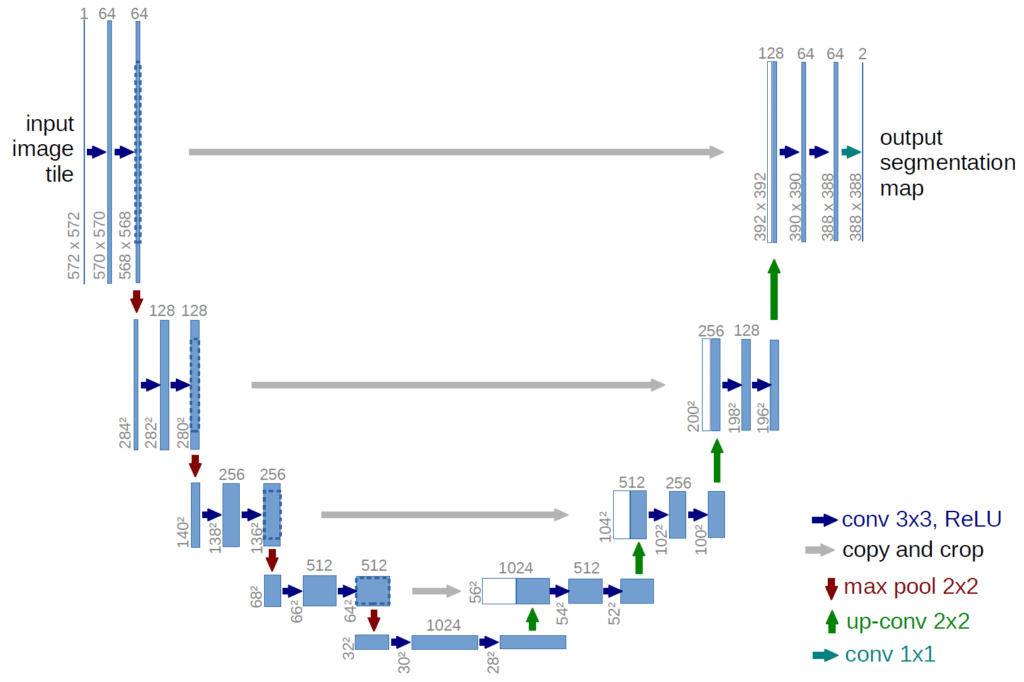</center>

A parte do codificador segue unha estrutura convencional de rede neuronal convolucional (CNN) para extraer características relevantes das imaxes de entrada. A imaxe de entrada é procesada en bloques, onde se lle aplican dúas capas convolucionais seguidas dunha capa de *pooling* para reducir a dimensión espacial das características extraídas. Cada capa convolucional utiliza un tamaño de filtro de 3x3 e unha función de activación ReLU para introducir non linealidade no modelo. A capa de *pooling* emprega unha operación de max-pooling con un tamaño de 2x2 para reducir a resolución das características, o que axuda a diminuír o número de parámetros e a evitar o sobreaxuste. Ao igual que nunha CNN básica, o número de filtros nas capas convolucionais duplícase por dous despois de cada capa de *pooling*, permitindo á rede capturar características máis complexas a medida que avanza.

A parte do decodificador segue unha estrutura simétrica á do codificador. As características obtidas do codificador son procesadas en bloques, onde se lle aplican un *upsampling* para aumentar a resolución seguido de dúas capas convolucionais. Cada capa convolucional tamén utiliza un tamaño de filtro de 3x3 e unha función de activación ReLU. Dependendo da implementación, as capa de *upsampling* consisten nunha operación de reescalado sinxela (utilizando interpolación) ou unha convolución trasposta. Neste caso, o número de filtros nas capas convolucionais do decodificador redúcese á metade despois de cada operación de *upsampling*, restaurando gradualmente a resolución orixinal da imaxe de entrada.

É tamén relevante que en cada nivel de profundidade da rede, as características do codificador son concatenadas coas características correspondentes do decodificador. Esta técnica, coñecida como "skip connections" ou conexións de salto, axuda a preservar a información espacial e os detalles finos da imaxe orixinal, facilitando unha mellor reconstrucción da imaxe de saída.


A continuación amósase un exemplo de código en Pytorch que implementa esta arquitectura:

In [5]:
class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=[64, 128, 256, 512]):
        super(UNet, self).__init__()
        self.encoder = nn.ModuleList()
        self.decoder = nn.ModuleList()
        # Encoder
        for feature in features:
            self.encoder.append(self.conv_block(in_channels, feature))
            in_channels = feature
        # Decoder
        for feature in reversed(features):
            self.decoder.append(
                nn.ConvTranspose2d(feature*2, feature, kernel_size=2, stride=2)
            )
            self.decoder.append(self.conv_block(feature*2, feature))
        self.bottleneck = self.conv_block(features[-1], features[-1]*2)
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def conv_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        skip_connections = []
        for layer in self.encoder:
            x = layer(x)
            skip_connections.append(x)
            x = nn.MaxPool2d(kernel_size=2)(x)
        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]
        for idx in range(0, len(self.decoder), 2):
            x = self.decoder[idx](x)
            skip_connection = skip_connections[idx//2]
            if x.shape != skip_connection.shape:
                x = TF.resize(x, size=skip_connection.shape[2:])
            x = torch.cat((skip_connection, x), dim=1)
            x = self.decoder[idx+1](x)
        return self.final_conv(x)

## Exercicio proposto

1. Crea un dataset xenérico (mediante unha clase que herde de `torch.utils.data.Dataset`). O constructor debe recibr como parámetro os directorios das imaxes e das máscaras, por exemplo `FruitSeg30/Apple_Gala/Images` e `FruitSeg30/Apple_Gala/Mask`. Este clase debe implementar ademáis os métodos `__len__` e `__getitem__`, de xeito que o primeiro devolva o número de imaxes no conxunto de datos, e o segundo devolva unha tupla `(imaxe, máscara)` para o índice dado. Para cargar as imaxes e máscaras, podes empregar a biblioteca `PIL`. Logo de cargar a imaxe e a máscara, aplícalles as transformacións necesarias para devolvelas como obxectos da clase `torch.Tensor` e cun tamaño de 128x128.
2. Crea os obxectos `Dataset` e `DataLoader` necesarios para cargar o conxunto de datos de imaxes e máscaras de segmentación. Deberás obter un dicionario no que as chaves sexan as categorías (`Apple_Gala`, `Apple_Golden Delicious`, etc.), e os valores sexan á súa vez dicionarios cuxas chaves serán `dataset_train`, `dataset_val`, `dataset_test`,  `dataloader_train`, `dataloader_val` e `dataloader_test`. Utiliza un tamaño de lote de 4 para o `Dataloader` de adestramento (os de validación e test poden levar calquera tamaño de lote) e un split aleatorio de 60%/20%/20% para a división entre conxuntos de adestramento, validación e test.

    Exemplo:

    ```python
    {
        'Apple_Gala': {
            'dataset_train': <Dataset object>,
            'dataset_val': <Dataset object>,
            'dataset_test': <Dataset object>,
            'dataloader_train': <DataLoader object>,
            'dataloader_val': <DataLoader object>,
            'dataloader_test': <DataLoader object>,
        },
        'Apple_Golden Delicious': {
            ...
        },
        ...
    }
    ```

3. Proba os modelos de segmentación DeepLabV3 e FCN, do paquete `torchvision.models.segmentation`, e a implementación da UNet proposta nesta práctica. Ten en conta o seguinte:
- Utiliza os `DataLoader` creados no exercicio anterior para adestrar e validar os modelos.
- Emprega como función de perda a entropía cruzada binaria, e como optimizador `Adam`.
- Adestra os modelos utilizando *early stopping* para evitar o sobreaxuste, é dicir, para o adestramento cando a perda obtida no conxunto de validación non mellore durante un número determinado de épocas. Quédate co modelo que obteña a mellor perda no conxunto de validación.
- Obtén as métricas Dice e Hausdorff no conxunto de test para cada modelo e cada categoría (se o adestramento consume moito tempo podes seleccionar un subconxunto de categorías, como mínimo 3). Compara os resultados obtidos cos distintos modelos, incluíndo na comparativa o número de parámetros de cada modelo.
- Xera visualizacións dos resultados obtidos. Para cada modelo e categoría, amosa o resultado da segmentación no mellor e no peor caso, utilizando a visualización TP, TN, FP e FN que se explicou na práctica anterior.
- Xustifica se as predicións se poderían mellorar empregando operacións morfolóxicas de postprocesado.
4. Contesta ás seguintes preguntas sobre a arquitectura UNet:
- Que cambios habería que facer na implementación da UNet para aumentar o número de niveis de profundidade?
- Poderíamos aumentar indefinidamente o número de niveis de profundidade da UNet ou existe algunha limitación?
- Se aumentamos o tamaño das imaxes de entrada, seguiría funcionando a implementación actual da UNet?

## Clase Dataset

In [6]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os
import torchvision.transforms as T

class SegmentationDataset(Dataset):
    def __init__(self, img_dir, masks_dir, size=128):
        self.transform_img = T.Compose([
            T.Resize((size, size)),
            T.ToTensor(),
        ])
        self.transform_mask = T.Compose([
            T.Resize((size, size), interpolation=Image.NEAREST),
            T.ToTensor(),
        ])

        self.image_mask_pairs = []
        image_files = sorted([f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.png', '.jpeg'))])

        for img_name in image_files:
            img_path = os.path.join(img_dir, img_name)

            #  LA LÍNEA CLAVE CORREGIDA
            # Separamos el nombre del archivo de su extensión (ej: '1', '.jpg')
            name_part, _ = os.path.splitext(img_name)
            # Construimos el nombre correcto de la máscara (ej: '1_mask.png')
            mask_name = name_part + '_mask.png'
            #  FIN DE LA CORRECCIÓN

            mask_path = os.path.join(masks_dir, mask_name)

            if os.path.exists(mask_path):
                self.image_mask_pairs.append((img_path, mask_path))

    def __len__(self):
        return len(self.image_mask_pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.image_mask_pairs[idx]
        imagen = Image.open(img_path).convert('RGB')
        mask = Image.open(mask_path).convert('L')
        imagen = self.transform_img(imagen)
        mask = self.transform_mask(mask)
        mask = (mask > 0.5).float()
        return imagen, mask

In [7]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset

directorios = [d.name for d in dataset_dir.iterdir() if d.is_dir()]
data_dicc = {}

class SubsetDS(SegmentationDataset): #copia parte do dataset
    def __init__(self, img_dir, masks_dir, indices, size=128):
        super().__init__(img_dir, masks_dir, size)
        self.indices = indices
    def __len__(self):
        return len(self.indices) #solo o número de índices no subconxunto
    def __getitem__(self, idx):
        return super().__getitem__(self.indices[idx]) #obtemos o elemento do índice orixinal

def subset_dataset(indices, img_dir, mask_dir):
    return SubsetDS(img_dir, mask_dir, indices)

data_dicc = {}

for dir in directorios:
    img_dir = dataset_dir / dir / 'Images'
    mask_dir = dataset_dir / dir / 'Mask'

    # 1. Crear UNA SOLA VEZ el dataset completo para la categoría
    #    Este dataset ya sabe cuántos pares válidos (imagen, máscara) existen
    full_dataset = SegmentationDataset(img_dir, mask_dir)

    # 2. Crear los índices basándose en el TAMAÑO REAL del dataset válido
    num_samples = len(full_dataset)
    idxs = list(range(num_samples))

    # 3. Dividir estos índices correctos
    train_idx, temp_idx = train_test_split(idxs, test_size=0.4, random_state=42)
    val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, random_state=42)

    # 4. Usar la clase Subset de PyTorch para crear los datasets de train/val/test
    #    Subset(dataset, indices) crea un subconjunto sin copiar los datos
    ds_train = Subset(full_dataset, train_idx)
    ds_val = Subset(full_dataset, val_idx)
    ds_test = Subset(full_dataset, test_idx)

    # 5. Crear los DataLoaders como antes
    data_dicc[dir] = {
        'dataset_train': ds_train,
        'dataset_val': ds_val,
        'dataset_test': ds_test,
        'dataloader_train': DataLoader(ds_train, batch_size=4, shuffle=True, drop_last=True),
        'dataloader_val': DataLoader(ds_val, batch_size=8, shuffle=False),
        'dataloader_test': DataLoader(ds_test, batch_size=8, shuffle=False),
    }

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.models.segmentation import fcn_resnet50, deeplabv3_resnet50
import numpy as np
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from scipy.spatial.distance import directed_hausdorff


#  Funciones para Métricas
# 2*|X interseccion Y| / (|X| + |Y|)
def dice_coefficient(pred, target, smooth=1e-6):
    pred = torch.sigmoid(pred) > 0.5
    pred_flat = pred.contiguous().view(-1)
    target_flat = target.contiguous().view(-1)
    intersection = (pred_flat * target_flat).sum()
    dice = (2. * intersection + smooth) / (pred_flat.sum() + target_flat.sum() + smooth)
    return dice.item()

# max{sup d(x,Y), sup d(X,y)}
def hausdorff_distance(pred, target):
    pred_coords = np.transpose(np.nonzero(pred.squeeze().cpu().numpy()))
    target_coords = np.transpose(np.nonzero(target.squeeze().cpu().numpy()))

    # La distancia de Hausdorff no está definida si un conjunto está vacío
    if len(pred_coords) == 0 or len(target_coords) == 0:
        return float('inf') # O un valor alto predefinido

    # Calcular la distancia de Hausdorff dirigida en ambas direcciones y tomar el máximo
    h1 = directed_hausdorff(pred_coords, target_coords)[0]
    h2 = directed_hausdorff(target_coords, pred_coords)[0]
    return max(h1, h2)


#  Función de Entrenamiento y Validación con Early Stopping

def adestrar_modelo(modelo, dataloaders, criterion, optimizer, device, num_epocas=25, patience=5):

    modelo.to(device)
    mejor_perdida_validacion = float('inf')
    paciencia = 0
    mellor_estado = None

    for epoca in range(num_epocas):

        # Fase de entrenamiento
        modelo.train()
        perdida_adestramento = 0.0

        for inputs, masks in dataloaders['dataloader_train']:

            inputs, masks = inputs.to(device), masks.to(device)

            optimizer.zero_grad()
            outputs = modelo(inputs)
            # torchvision devolven un dict, a UNet non
            # se outputs é un dict, obtemos 'out'
            if isinstance(outputs, dict):
                outputs = outputs['out']

            perdida = criterion(outputs, masks)
            perdida.backward()
            optimizer.step()
            perdida_adestramento += perdida.item() * inputs.size(0)

        perdida_epoca = perdida_adestramento / len(dataloaders['dataset_train'])

        # Fase de validación
        modelo.eval()
        perdida_validacion = 0.0
        with torch.no_grad():
            for inputs, masks in dataloaders['dataloader_val']:
                inputs, masks = inputs.to(device), masks.to(device)
                outputs = modelo(inputs)
                if isinstance(outputs, dict):
                    outputs = outputs['out']
                loss = criterion(outputs, masks)
                perdida_validacion += loss.item() * inputs.size(0)

        perdida_validacion /= len(dataloaders['dataset_val'])
        print(f'Época {epoca+1}/{num_epocas}, Pérdida {perdida_epoca:.4f}, Pérdida Validación: {perdida_validacion:.4f}')

        # Lóxica de Early Stopping
        if perdida_validacion < mejor_perdida_validacion:
            mejor_perdida_validacion = perdida_validacion
            paciencia = 0
            mellor_estado = modelo.state_dict()
        else:
            paciencia += 1
            if paciencia >= patience:
                print(f'Early stopping na época {epoca+1}')
                break

    #  mellor modelo
    modelo.load_state_dict(mellor_estado)
    return modelo

#  Función de avaliacion en el conjunto de Test

def avaliar_modelo(modelo, dataloader_test, device):
    modelo.eval()
    modelo.to(device)
    metrica_dice = []
    metrica_hausdorff = []

    mellor_caso = {'score': -1, 'data': None}
    peor_caso = {'score': 2, 'data': None} # Dice va de 0 a 1

    with torch.no_grad():
        for inputs, masks in dataloader_test:
            inputs, masks = inputs.to(device), masks.to(device)
            outputs = modelo(inputs)
            if isinstance(outputs, dict):
                outputs = outputs['out']

            # Iterar sobre cada imaxe
            for j in range(inputs.size(0)):

                pred = torch.sigmoid(outputs[j]) > 0.5
                mask = masks[j]

                #cálcul das métricas
                dice = dice_coefficient(outputs[j], mask)
                hd = hausdorff_distance(pred, mask)

                metrica_dice.append(dice)
                if hd != float('inf'): #só distancias válidas!!
                    metrica_hausdorff.append(hd)

                # Gardar casos (basados en Dice)
                if dice > mellor_caso['score']:
                    mellor_caso['score'] = dice
                    mellor_caso['data'] = (inputs[j].cpu(), mask.cpu(), pred.cpu())
                if dice < peor_caso['score']:
                    peor_caso['score'] = dice
                    peor_caso['data'] = (inputs[j].cpu(), mask.cpu(), pred.cpu())

    dice_promedio = np.mean(metrica_dice)
    hd_promedio = np.mean(metrica_hausdorff) if metrica_hausdorff else float('nan')

    return dice_promedio, hd_promedio, mellor_caso, peor_caso

#  Función de Visualización
def resultados(imaxe, true_mask, pred_mask, titulo):
    true_mask = true_mask.squeeze().numpy()
    pred_mask = pred_mask.squeeze().numpy()

    # Calcular TP, FP e FN
    tp = np.logical_and(true_mask, pred_mask)
    fp = np.logical_and(np.logical_not(true_mask), pred_mask)
    fn = np.logical_and(true_mask, np.logical_not(pred_mask))

    #  imaxen de visualización
    overlay = np.zeros((imaxe.shape[1], imaxe.shape[2], 3), dtype=np.uint8)
    overlay[tp] = [255, 255, 255]  # Blanco
    overlay[fp] = [255, 0, 0]    # Vermello
    overlay[fn] = [0, 0, 255]    # Azul ¡

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    fig.suptitle(titulo, fontsize=16)

    axes[0].imshow(imaxe.permute(1, 2, 0))
    axes[0].set_title("Imagen Original")
    axes[0].axis('off')

    axes[1].imshow(true_mask, cmap='gray')
    axes[1].set_title("Máscara Real ")
    axes[1].axis('off')

    axes[2].imshow(pred_mask, cmap='gray')
    axes[2].set_title("Máscara Modelada")
    axes[2].axis('off')

    axes[3].imshow(overlay)
    axes[3].set_title("Visualización (TP: Blanco, FP: Vermello, FN: Azul)")
    axes[3].axis('off')

    plt.show()

In [10]:
#  Configuración del Experimento
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Executando na {device}")

# Seleccionar un subconjunto de categorías para probar
categorias = ['Apple_Gala', 'Banana', 'Orange']

# Definir los modelos a probar
modelos = {
    "UNet": UNet(in_channels=3, out_channels=1),
    "FCN_ResNet50": fcn_resnet50(weights=None, num_classes=1),
    "DeepLabV3_ResNet50": deeplabv3_resnet50(weights=None, num_classes=1)
}

resultados_train = {}

#  Bucle Principal
for categoria in categorias:
    print(f" Adestrando en : {categoria} ")
    resultados_train[categoria] = {}
    dataloaders = data_dicc[categoria]

    for modelo_nome, modelo in modelos.items():
        print(f"\n Entrenando modelo: {modelo_nome} ")

        # Contar parámetros del modelo
        num_params = sum(p.numel() for p in modelo.parameters() if p.requires_grad)


        criterion = nn.BCEWithLogitsLoss() # Da un error raro se utilizo BCELoss
        optimizer = optim.Adam(modelo.parameters(), lr=1e-4)

        # Adestrar
        trained_modelo = adestrar_modelo(modelo, dataloaders, criterion, optimizer, device, num_epocas=30, patience=5)

        # Avaliar
        avg_dice, avg_hausdorff, mellor_caso, peor_caso = avaliar_modelo(trained_modelo, dataloaders['dataloader_test'], device)

        # Gardar resultados
        resultados_train[categoria][modelo_nome] = {
            "params": f"{num_params/1e6:.2f}M",
            "avg_dice": avg_dice,
            "avg_hausdorff": avg_hausdorff
        }

        print(f"\nResultados para {modelo_nome} en {categoria}:")
        print(f"  - Parámetros: {resultados_train[categoria][modelo_nome]['params']}")
        print(f"  - Dice promedio (test): {avg_dice:.4f}")
        print(f"  - Hausdorff promedio (test): {avg_hausdorff:.4f}")

        # Visualizar mejor y peor caso
        print("\nVisualizando mejor caso...")
        resultados(*mellor_caso['data'], titulo=f"Mejor Caso - {modelo_nome} en {categoria} (Dice: {mellor_caso['score']:.4f})")

        print("\nVisualizando peor caso...")
        resultados(*peor_caso['data'], titulo=f"Peor Caso - {modelo_nome} en {categoria} (Dice: {peor_caso['score']:.4f})")

Executando na cuda
 Adestrando en : Apple_Gala 

 Entrenando modelo: UNet 


AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


la profundidad de la red está controlada por la lista features en el constructor `__init__`. Esta lista define el número de filtros en cada nivel del codificador.

Para aumentar el número de niveles de profundidad, simplemente habría que añadir más elementos a la lista features.

Por ejemplo, la implementación actual tiene 4 niveles `(features=[64, 128, 256, 512])`. Para pasar a 5 niveles, se modificaría así:
~~~python
# UNet original con 4 niveles de profundidad
model_4_levels = UNet(features=[64, 128, 256, 512])

# UNet modificada con 5 niveles de profundidad
model_5_levels = UNet(features=[64, 128, 256, 512, 1024])
~~~
  

Los bucles que construyen el codificador `(self.encoder)` y el decodificador `(self.decoder)` iteran sobre esta lista, por lo que se adaptarían automáticamente para crear una red más profunda con un nivel adicional de MaxPool2d en el codificador y ConvTranspose2d en el decodificador

No, no se puede aumentar indefinidamente. Existen dos limitaciones principales:  

Limitación Espacial (Tamaño de la Imagen): La limitación más estricta es el tamaño de la imagen de entrada. Cada nivel de profundidad en el codificador incluye una capa de MaxPool2d con un kernel_size=2, que divide por 2 las dimensiones espaciales (alto y ancho) del mapa de características. Si tienes una imagen de entrada de 128x128, puedes aplicar esta operación un máximo de 7 veces (128 -> 64 -> 32 -> 16 -> 8 -> 4 -> 2 -> 1). Después de 7 niveles, el mapa de características sería de 1x1, y ya no se podría reducir más. Intentar añadir un octavo nivel provocaría un error o un mapa de características de tamaño 0x0. La implementación actual, con 4 niveles, reduce una imagen de 128x128 a 8x8 en la parte más profunda antes del bottleneck.  

Limitación Computacional (Memoria de la GPU): Cada nivel de profundidad adicional aumenta significativamente el número de parámetros y, sobre todo, la cantidad de memoria necesaria para almacenar las activaciones durante el entrenamiento. Redes muy profundas pueden no caber en la memoria de una GPU estándar, lo que hace su entrenamiento inviable sin técnicas avanzadas o hardware más poten

Sí, seguiría funcionando perfectamente. Esta es una de las grandes ventajas de las arquitecturas totalmente convolucionales (Fully Convolutional Networks, FCNs) como la U-Net.  

La razón es que no contiene ninguna capa que exija un tamaño de entrada fijo (como las capas Linear o Flatten al final de una red de clasificación típica). Todas las operaciones (convoluciones, pooling, etc.) se aplican localmente y pueden operar sobre imágenes de cualquier tamaño.